In [46]:
# построение ковра Серпинского
# c помощью ДСИФ

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [47]:
# Ячейка № 2

# задание функции, возвращающей
# правила итераций
def Rule(Digit):
    Tmp_list = []

    for i in range(3**Digit):
        Str_Digit = ""
        Number = i
        while Number > 0:
            Str_Digit = str(Number % 3) + Str_Digit
            Number = Number // 3
        if i == 0:
            Tmp_list.append("0")
        else:
            Tmp_list.append(Str_Digit)

    return Tmp_list


In [ ]:
# Ячейка № 3

# задание функции, возвращающей изображение
# треугольного ковра Серпинского
# с помощью системы итеритрованных функций
def Serpynsky_DSIF(N_Iter, N_Points):
    # входные переменные:
    # N_Iter - порядок ковра
    # N_Points - число точек
    #            начальной конфигурации

    # задание координат вершин
    # базового треугольника
    x1 = 0
    y1 = 0
    x2 = 1
    y2 = 1
    x3 = 1 / 2
    y3 = np.sin(np.pi / 3)
    j = 1

    # инициализация массивов, используемых
    # хранения координат точек начальной
    # конфигурации
    x = np.zeros(N_Points)
    y = np.zeros(N_Points)

    # инициализация генератора случайных чисел
    np.random.seed()

    # задание координат точек
    # начальной конфигурации
    while j <= N_Points:
        Tmp_X = np.random.uniform(0, 1)
        Tmp_Y = np.sqrt(3) / 2 * np.random.uniform(0, 1)
        if (
            -np.sqrt(3) * Tmp_X + Tmp_Y <= 0
            and np.sqrt(3) * Tmp_X + Tmp_Y - np.sqrt(3) <= 0
        ):
            x[j - 1] = Tmp_X
            y[j - 1] = Tmp_Y
            j = j + 1
    # создание массива, содержащего правила итераций
    Tmp = Rule(N_Iter)
    s = "0" * N_Iter
    Cod_list = []
    for i in range(3**N_Iter):
        tmp = list(Tmp[i])
        tmp1 = list(s)
        for m in range(len(tmp)):
            tmp1[N_Iter - m - 1] = tmp[len(tmp) - m - 1]
        Cod_list.append(tmp1)

    # задание аффинных преобразований
    a1 = np.array([0, 0])
    a2 = np.array([1 / 2, 0])
    a3 = np.array([1 / 4, np.sqrt(3) / 4])
    A = np.array([[1 / 2, 0], [0, 1 / 2]])

    # создание графического окна
    F = plt.figure(figsize=(8, 8))
    ax = F.add_subplot()
    polygon1 = np.array([[x1, y1], [x2, y2], [x3, y3]])

    # визуализация базового треугольника
    ax.add_patch(plt.Polygon(polygon1, facecolor="white"))
    plt.axis("equal")
    plt.axis("off")

    # визуализация треугольного ковра Серпинского
    Draw_Fractal(N_Iter, N_Points, x, y, A, a1, a2, a3, Cod_list)

    plt.show()

In [49]:
# Ячейка № 4

# задание функции, создающей
# изображение треугольного
# ковра Серпинского


def Draw_Fractal(N_Iter, N_Points, x, y, A, a1, a2, a3, Cod_list):
    for m in range(3**N_Iter):
        X = x[:]
        Y = y[:]
        Rule_Step_list = Cod_list[m]
        for i in range(N_Iter):
            Tmp = Rule_Step_list[N_Iter - 1 - i]
            if Tmp == "0":
                [X, Y] = Affin_Transform(N_Points, X, Y, A, a1)
            if Tmp == "1":
                [X, Y] = Affin_Transform(N_Points, X, Y, A, a2)
            if Tmp == "2":
                [X, Y] = Affin_Transform(N_Points, X, Y, A, a3)

        plt.plot(X, Y, ".k", markersize=0.1)

In [ ]:
# Ячейка № 5

# задание функции, возвращающей
# результат аффинных преобразований
# координат точек
def Affin_Transform(N_Points, X, Y, A, a):
    x_Tr = np.zeros(N_Points)
    y_Tr = np.zeros(N_Points)
    for i in range(N_Points):
        R = np.array([X[i], Y[i]])
        R = A.dot(R) + a
        x_Tr[i] = R[0]
        y_Tr[i] = R[1]
    return x_Tr, y_Tr

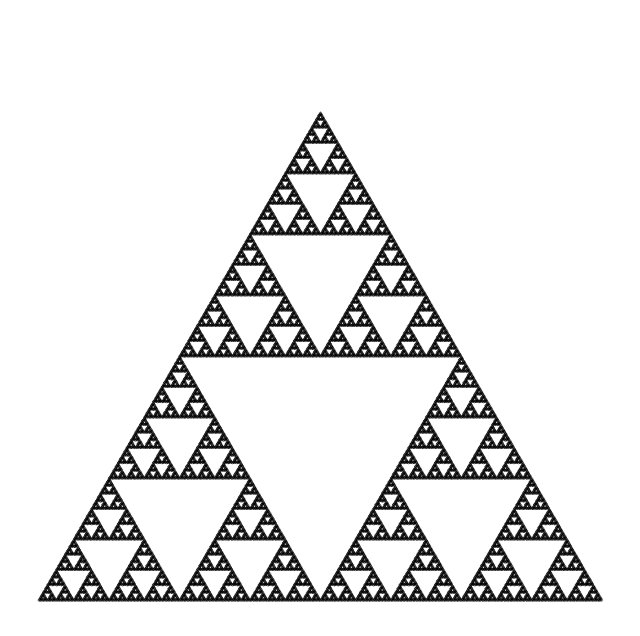

In [51]:
# Ячейка № 6

# визуализация треугольного
# ковра Серпинского с помощью ДСИФ

Serpynsky_DSIF(7, 100)